In [1]:
# Import required libraries
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from joblib import dump, load
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    precision_recall_fscore_support,
    r2_score,
)
import warnings

warnings.filterwarnings('ignore')

# To display plots inside notebook
%matplotlib inline

print("✅ Libraries imported successfully!")


✅ Libraries imported successfully!


In [2]:
# Step 1: Setup folders and discover available data files
data_folder = "data"
models_folder = "models"

# Create models folder if it doesn't exist
os.makedirs(models_folder, exist_ok=True)

# Discover available CSV files in data folder
csv_files = [f for f in os.listdir(data_folder) if f.endswith('.csv')]
print(f"📁 Found {len(csv_files)} CSV files in data folder:")
for csv_file in csv_files:
    print(f"   - {csv_file}")

# Extract stock names from CSV files
stock_names = [f.replace('_NS.csv', '') for f in csv_files if '_NS.csv' in f]
print(f"\n📊 Available stocks: {stock_names}")


📁 Found 6 CSV files in data folder:
   - HDFCBANK_NS.csv
   - ICICIBANK_NS.csv
   - INFY_NS.csv
   - RELIANCE_NS.csv
   - SBIN_NS.csv
   - TCS_NS.csv

📊 Available stocks: ['HDFCBANK', 'ICICIBANK', 'INFY', 'RELIANCE', 'SBIN', 'TCS']


In [3]:
# Step 2: Function to load and preprocess data from CSV
def load_stock_data(csv_filename):
    """
    Load stock data from CSV file and preprocess it.
    
    Args:
        csv_filename: Name of the CSV file (e.g., 'TCS_NS.csv')
    
    Returns:
        DataFrame with preprocessed stock data
    """
    csv_path = os.path.join(data_folder, csv_filename)
    
    if not os.path.exists(csv_path):
        print(f"❌ File not found: {csv_path}")
        return None
    
    # Load CSV
    df = pd.read_csv(csv_path, parse_dates=['Date'])
    df.set_index('Date', inplace=True)
    
    # Sort by date
    df.sort_index(inplace=True)
    
    # Drop any missing values
    df = df.dropna()
    
    # Ensure we have required columns
    required_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
    if not all(col in df.columns for col in required_cols):
        print(f"⚠️ Missing required columns in {csv_filename}")
        return None
    
    print(f"✅ Loaded {csv_filename}: {len(df)} rows, Date range: {df.index[0].date()} to {df.index[-1].date()}")
    return df

# Test loading one file
if csv_files:
    test_file = csv_files[0]
    test_data = load_stock_data(test_file)
    if test_data is not None:
        print(f"\n📊 Sample data from {test_file}:")
        print(test_data.head())



✅ Loaded HDFCBANK_NS.csv: 2609 rows, Date range: 2015-01-01 to 2024-12-31

📊 Sample data from HDFCBANK_NS.csv:
                  Open        High         Low       Close   Volume
Date                                                               
2015-01-01  101.736677  102.923173  100.263086  101.823457  2240171
2015-01-02  101.665617  102.154459   99.904613  101.098699  2946842
2015-01-05  102.046845  102.244645  101.116336  101.681020  2231146
2015-01-06   99.960732  101.191355   99.449585  100.215745  2331091
2015-01-07  100.029479  101.726163   99.712923  100.177857  3260725


In [4]:
# Step 3: Function to train model for a single stock
def train_stock_model(stock_name):
    """
    Train a Linear Regression model for a stock using CSV data.
    
    Args:
        stock_name: Stock name (e.g., 'TCS', 'RELIANCE')
    
    Returns:
        Dictionary with model metrics or None if training fails
    """
    csv_filename = f"{stock_name}_NS.csv"
    csv_path = os.path.join(data_folder, csv_filename)
    
    if not os.path.exists(csv_path):
        print(f"  ⚠️ CSV file not found: {csv_filename}")
        return None
    
    # Load data
    df = load_stock_data(csv_filename)
    if df is None or len(df) < 50:
        print(f"  ⚠️ Not enough data for {stock_name} (need at least 50 rows)")
        return None
    
    # Prepare features and target
    # Using Open, High, Low, Volume to predict Close
    X = df[['Open', 'High', 'Low', 'Volume']]
    y = df['Close']
    
    # Split data (80% train, 20% test, no shuffle to preserve time series)
    split_idx = int(len(X) * 0.8)
    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]
    
    # Train model
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    # Evaluate on test set
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    # Calculate metrics
    train_mae = mean_absolute_error(y_train, y_pred_train)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
    test_mae = mean_absolute_error(y_test, y_pred_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    test_r2 = r2_score(y_test, y_pred_test)
    
    # Save model
    model_filename = f"{stock_name}_NS_model.joblib"
    model_path = os.path.join(models_folder, model_filename)
    dump(model, model_path)
    
    print(f"  ✅ Model saved: {model_filename}")
    print(f"     Train MAE: {train_mae:.2f}, RMSE: {train_rmse:.2f}")
    print(f"     Test  MAE: {test_mae:.2f}, RMSE: {test_rmse:.2f}, R²: {test_r2:.4f}")
    
    return {
        'Stock': stock_name,
        'Train_MAE': round(train_mae, 3),
        'Train_RMSE': round(train_rmse, 3),
        'Test_MAE': round(test_mae, 3),
        'Test_RMSE': round(test_rmse, 3),
        'Test_R2': round(test_r2, 4),
        'Data_Points': len(df)
    }

# Test training for one stock
if stock_names:
    print(f"\n🧪 Testing model training for {stock_names[0]}...")
    result = train_stock_model(stock_names[0])
    if result:
        print(f"\n✅ Test successful!")



🧪 Testing model training for HDFCBANK...
✅ Loaded HDFCBANK_NS.csv: 2609 rows, Date range: 2015-01-01 to 2024-12-31
  ✅ Model saved: HDFCBANK_NS_model.joblib
     Train MAE: 0.23, RMSE: 0.29
     Test  MAE: 0.23, RMSE: 0.29, R²: 0.9995

✅ Test successful!


In [5]:
# Step 4: Train models for all available stocks
print("=" * 70)
print("🚀 TRAINING MODELS FOR ALL STOCKS")
print("=" * 70)

results = []
for stock_name in stock_names:
    print(f"\n📈 Training model for {stock_name}...")
    result = train_stock_model(stock_name)
    if result:
        results.append(result)

# Create accuracy report
if results:
    report_df = pd.DataFrame(results)
    report_df.to_csv('accuracy_report.csv', index=False)
    print("\n" + "=" * 70)
    print("📊 ACCURACY REPORT")
    print("=" * 70)
    print(report_df.to_string(index=False))
    print(f"\n✅ Accuracy report saved to: accuracy_report.csv")
else:
    print("\n❌ No models were trained successfully.")



🚀 TRAINING MODELS FOR ALL STOCKS

📈 Training model for HDFCBANK...
✅ Loaded HDFCBANK_NS.csv: 2609 rows, Date range: 2015-01-01 to 2024-12-31
  ✅ Model saved: HDFCBANK_NS_model.joblib
     Train MAE: 0.23, RMSE: 0.29
     Test  MAE: 0.23, RMSE: 0.29, R²: 0.9995

📈 Training model for ICICIBANK...
✅ Loaded ICICIBANK_NS.csv: 2609 rows, Date range: 2015-01-01 to 2024-12-31
  ✅ Model saved: ICICIBANK_NS_model.joblib
     Train MAE: 0.23, RMSE: 0.28
     Test  MAE: 0.23, RMSE: 0.28, R²: 0.9976

📈 Training model for INFY...
✅ Loaded INFY_NS.csv: 2609 rows, Date range: 2015-01-01 to 2024-12-31
  ✅ Model saved: INFY_NS_model.joblib
     Train MAE: 0.23, RMSE: 0.29
     Test  MAE: 0.22, RMSE: 0.28, R²: 0.9988

📈 Training model for RELIANCE...
✅ Loaded RELIANCE_NS.csv: 2609 rows, Date range: 2015-01-01 to 2024-12-31
  ✅ Model saved: RELIANCE_NS_model.joblib
     Train MAE: 0.24, RMSE: 0.29
     Test  MAE: 0.23, RMSE: 0.29, R²: 0.9989

📈 Training model for SBIN...
✅ Loaded SBIN_NS.csv: 2609 rows, D


📊 ACCURACY REPORT
    Stock  Train_MAE  Train_RMSE  Test_MAE  Test_RMSE  Test_R2  Data_Points
 HDFCBANK      0.228       0.286     0.231      0.293   0.9995         2609
ICICIBANK      0.227       0.284     0.228      0.284   0.9976         2609
     INFY      0.232       0.290     0.223      0.281   0.9988         2609
 RELIANCE      0.235       0.293     0.233      0.290   0.9989         2609
     SBIN      0.231       0.289     0.232      0.285   0.9983         2609
      TCS      0.240       0.301     0.231      0.286   0.9997         2609

✅ Accuracy report saved to: accuracy_report.csv



📊 Visualizing predictions for HDFCBANK...
✅ Loaded HDFCBANK_NS.csv: 2609 rows, Date range: 2015-01-01 to 2024-12-31


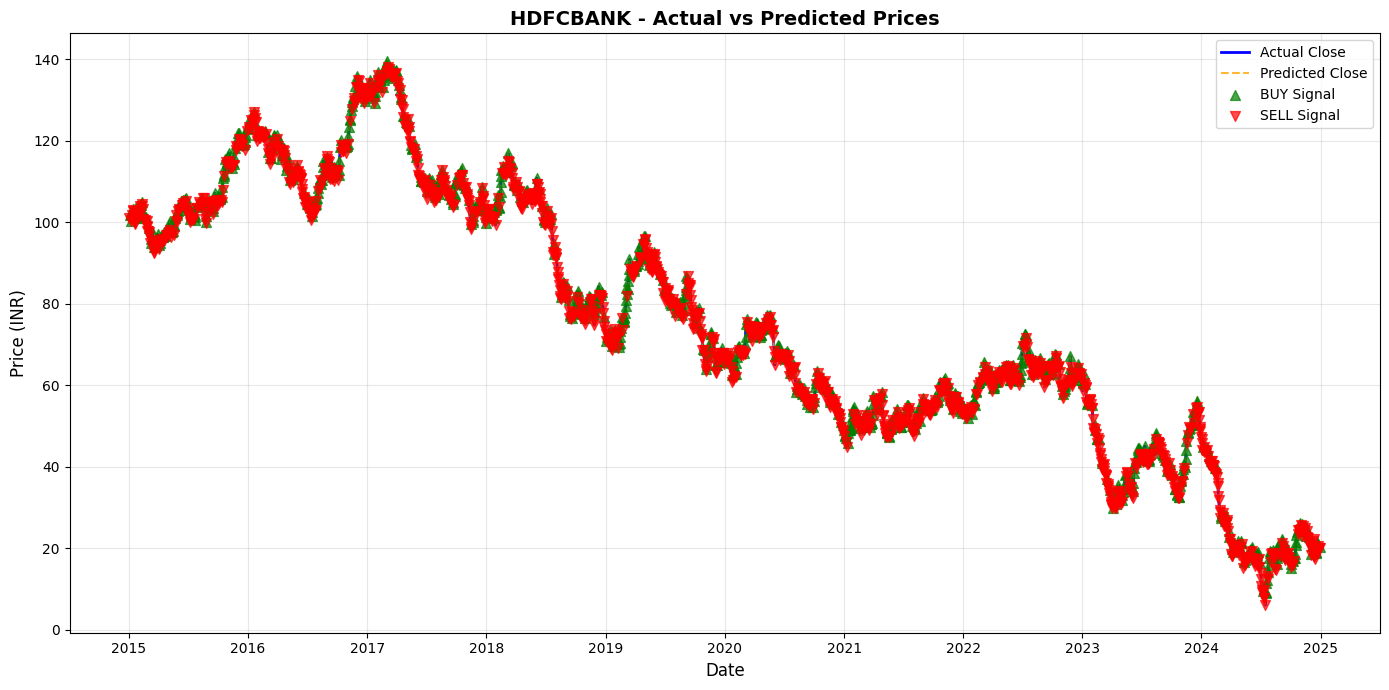


📊 Model Performance Metrics for HDFCBANK:
   Mean Absolute Error (MAE): 0.23
   Root Mean Squared Error (RMSE): 0.29
   R² Score: 0.9999

📈 Recent Predictions (Last 10 days):
                Close  Predicted_Close Signal
Date                                         
2024-12-18  18.520752        18.343247   SELL
2024-12-19  21.269165        21.043529    BUY
2024-12-20  21.396237        21.350282    BUY
2024-12-23  20.570825        20.639585   SELL
2024-12-24  19.091992        19.010665   SELL
2024-12-25  21.006652        20.895464    BUY
2024-12-26  19.976605        20.237643   SELL
2024-12-27  20.122772        19.811769   SELL
2024-12-30  19.953620        19.903134   SELL
2024-12-31  20.368010        20.264761    BUY


In [6]:
# Step 5: Visualize predictions for a specific stock
def visualize_predictions(stock_name, show_signals=True):
    """
    Load a trained model and visualize actual vs predicted prices.
    
    Args:
        stock_name: Stock name (e.g., 'TCS', 'RELIANCE')
        show_signals: Whether to show BUY/SELL signals
    """
    csv_filename = f"{stock_name}_NS.csv"
    model_filename = f"{stock_name}_NS_model.joblib"
    
    csv_path = os.path.join(data_folder, csv_filename)
    model_path = os.path.join(models_folder, model_filename)
    
    if not os.path.exists(csv_path):
        print(f"❌ CSV file not found: {csv_filename}")
        return
    
    if not os.path.exists(model_path):
        print(f"❌ Model file not found: {model_filename}")
        return
    
    # Load data
    df = load_stock_data(csv_filename)
    if df is None:
        return
    
    # Load model
    model = load(model_path)
    
    # Prepare features
    X = df[['Open', 'High', 'Low', 'Volume']]
    
    # Make predictions
    df['Predicted_Close'] = model.predict(X)
    
    # Generate BUY/SELL signals (BUY if predicted > previous actual close)
    df['Prev_Close'] = df['Close'].shift(1)
    df['Signal'] = np.where(df['Predicted_Close'] > df['Prev_Close'], 'BUY', 'SELL')
    df = df.dropna()
    
    # Plot
    plt.figure(figsize=(14, 7))
    plt.plot(df.index, df['Close'], label='Actual Close', linewidth=2, color='blue')
    plt.plot(df.index, df['Predicted_Close'], label='Predicted Close', linewidth=1.5, 
             linestyle='--', color='orange', alpha=0.8)
    
    if show_signals:
        buy_signals = df[df['Signal'] == 'BUY']
        sell_signals = df[df['Signal'] == 'SELL']
        
        plt.scatter(buy_signals.index, buy_signals['Close'], 
                   marker='^', color='green', s=50, label='BUY Signal', zorder=5, alpha=0.7)
        plt.scatter(sell_signals.index, sell_signals['Close'], 
                   marker='v', color='red', s=50, label='SELL Signal', zorder=5, alpha=0.7)
    
    plt.title(f"{stock_name} - Actual vs Predicted Prices", fontsize=14, fontweight='bold')
    plt.xlabel("Date", fontsize=12)
    plt.ylabel("Price (INR)", fontsize=12)
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Calculate and display metrics
    mae = mean_absolute_error(df['Close'], df['Predicted_Close'])
    rmse = np.sqrt(mean_squared_error(df['Close'], df['Predicted_Close']))
    r2 = r2_score(df['Close'], df['Predicted_Close'])
    
    print(f"\n📊 Model Performance Metrics for {stock_name}:")
    print(f"   Mean Absolute Error (MAE): {mae:.2f}")
    print(f"   Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"   R² Score: {r2:.4f}")
    
    # Show recent predictions
    print(f"\n📈 Recent Predictions (Last 10 days):")
    display_cols = ['Close', 'Predicted_Close', 'Signal']
    print(df[display_cols].tail(10).to_string())

# Visualize for the first available stock
if stock_names:
    print(f"\n📊 Visualizing predictions for {stock_names[0]}...")
    visualize_predictions(stock_names[0])


In [7]:
# Step 6: Predict next day price for a specific stock
def predict_next_day(stock_name):
    """
    Predict the next day's closing price for a stock.
    
    Args:
        stock_name: Stock name (e.g., 'TCS', 'RELIANCE')
    """
    csv_filename = f"{stock_name}_NS.csv"
    model_filename = f"{stock_name}_NS_model.joblib"
    
    csv_path = os.path.join(data_folder, csv_filename)
    model_path = os.path.join(models_folder, model_filename)
    
    if not os.path.exists(csv_path):
        print(f"❌ CSV file not found: {csv_filename}")
        return
    
    if not os.path.exists(model_path):
        print(f"❌ Model file not found: {model_filename}")
        return
    
    # Load data
    df = load_stock_data(csv_filename)
    if df is None:
        return
    
    # Load model
    model = load(model_path)
    
    # Get the latest row for prediction
    latest_data = df.tail(1)
    X_latest = latest_data[['Open', 'High', 'Low', 'Volume']]
    
    # Predict
    next_day_pred = model.predict(X_latest)[0]
    last_close = latest_data['Close'].iloc[0]
    last_date = latest_data.index[0]
    
    print(f"\n🔮 Prediction for {stock_name}:")
    print(f"   📅 Latest Date: {last_date.date()}")
    print(f"   💰 Last Closing Price: ₹{last_close:.2f}")
    print(f"   🔮 Predicted Next Closing Price: ₹{next_day_pred:.2f}")
    
    change = next_day_pred - last_close
    change_pct = (change / last_close) * 100
    direction = "📈 UP" if change > 0 else "📉 DOWN"
    
    print(f"   {direction}: ₹{abs(change):.2f} ({abs(change_pct):.2f}%)")

# Predict for the first available stock
if stock_names:
    print(f"\n🔮 Making prediction for {stock_names[0]}...")
    predict_next_day(stock_names[0])



🔮 Making prediction for HDFCBANK...
✅ Loaded HDFCBANK_NS.csv: 2609 rows, Date range: 2015-01-01 to 2024-12-31

🔮 Prediction for HDFCBANK:
   📅 Latest Date: 2024-12-31
   💰 Last Closing Price: ₹20.37
   🔮 Predicted Next Closing Price: ₹20.26
   📉 DOWN: ₹0.10 (0.51%)


In [8]:
# Step 7: Batch predictions for all stocks
print("=" * 70)
print("🔮 BATCH PREDICTIONS FOR ALL STOCKS")
print("=" * 70)

predictions_summary = []
for stock_name in stock_names:
    csv_filename = f"{stock_name}_NS.csv"
    model_filename = f"{stock_name}_NS_model.joblib"
    
    csv_path = os.path.join(data_folder, csv_filename)
    model_path = os.path.join(models_folder, model_filename)
    
    if not os.path.exists(csv_path) or not os.path.exists(model_path):
        continue
    
    try:
        # Load data and model
        df = load_stock_data(csv_filename)
        if df is None or len(df) == 0:
            continue
        
        model = load(model_path)
        
        # Get latest data
        latest_data = df.tail(1)
        X_latest = latest_data[['Open', 'High', 'Low', 'Volume']]
        
        # Predict
        next_day_pred = model.predict(X_latest)[0]
        last_close = latest_data['Close'].iloc[0]
        last_date = latest_data.index[0]
        
        change = next_day_pred - last_close
        change_pct = (change / last_close) * 100
        
        predictions_summary.append({
            'Stock': stock_name,
            'Last_Date': last_date.date(),
            'Last_Close': round(last_close, 2),
            'Predicted_Close': round(next_day_pred, 2),
            'Change': round(change, 2),
            'Change_%': round(change_pct, 2),
            'Signal': 'BUY' if change > 0 else 'SELL'
        })
        
        print(f"✅ {stock_name}: ₹{last_close:.2f} → ₹{next_day_pred:.2f} ({change_pct:+.2f}%)")
        
    except Exception as e:
        print(f"❌ Error predicting for {stock_name}: {str(e)}")
        continue

if predictions_summary:
    summary_df = pd.DataFrame(predictions_summary)
    print("\n" + "=" * 70)
    print("📊 PREDICTIONS SUMMARY")
    print("=" * 70)
    print(summary_df.to_string(index=False))
    print("\n✅ All predictions completed!")
else:
    print("\n❌ No predictions were made.")


🔮 BATCH PREDICTIONS FOR ALL STOCKS
✅ Loaded HDFCBANK_NS.csv: 2609 rows, Date range: 2015-01-01 to 2024-12-31
✅ HDFCBANK: ₹20.37 → ₹20.26 (-0.51%)
✅ Loaded ICICIBANK_NS.csv: 2609 rows, Date range: 2015-01-01 to 2024-12-31
✅ ICICIBANK: ₹106.95 → ₹107.02 (+0.06%)
✅ Loaded INFY_NS.csv: 2609 rows, Date range: 2015-01-01 to 2024-12-31
✅ INFY: ₹-27.85 → ₹-27.87 (+0.08%)
✅ Loaded RELIANCE_NS.csv: 2609 rows, Date range: 2015-01-01 to 2024-12-31
✅ RELIANCE: ₹85.62 → ₹85.34 (-0.33%)
✅ Loaded SBIN_NS.csv: 2609 rows, Date range: 2015-01-01 to 2024-12-31
✅ SBIN: ₹10.09 → ₹10.42 (+3.21%)
✅ Loaded TCS_NS.csv: 2609 rows, Date range: 2015-01-01 to 2024-12-31
✅ TCS: ₹149.45 → ₹149.51 (+0.04%)

📊 PREDICTIONS SUMMARY
    Stock  Last_Date  Last_Close  Predicted_Close  Change  Change_% Signal
 HDFCBANK 2024-12-31       20.37            20.26   -0.10     -0.51   SELL
ICICIBANK 2024-12-31      106.95           107.02    0.06      0.06    BUY
     INFY 2024-12-31      -27.85           -27.87   -0.02      0.08  

       Stock  Train_MAE  Train_RMSE  Test_MAE  Test_RMSE  Test_R2  Data_Points
0   HDFCBANK      0.228       0.286     0.231      0.293   0.9995         2609
1  ICICIBANK      0.227       0.284     0.228      0.284   0.9976         2609
2       INFY      0.232       0.290     0.223      0.281   0.9988         2609
3   RELIANCE      0.235       0.293     0.233      0.290   0.9989         2609
4       SBIN      0.231       0.289     0.232      0.285   0.9983         2609
5        TCS      0.240       0.301     0.231      0.286   0.9997         2609


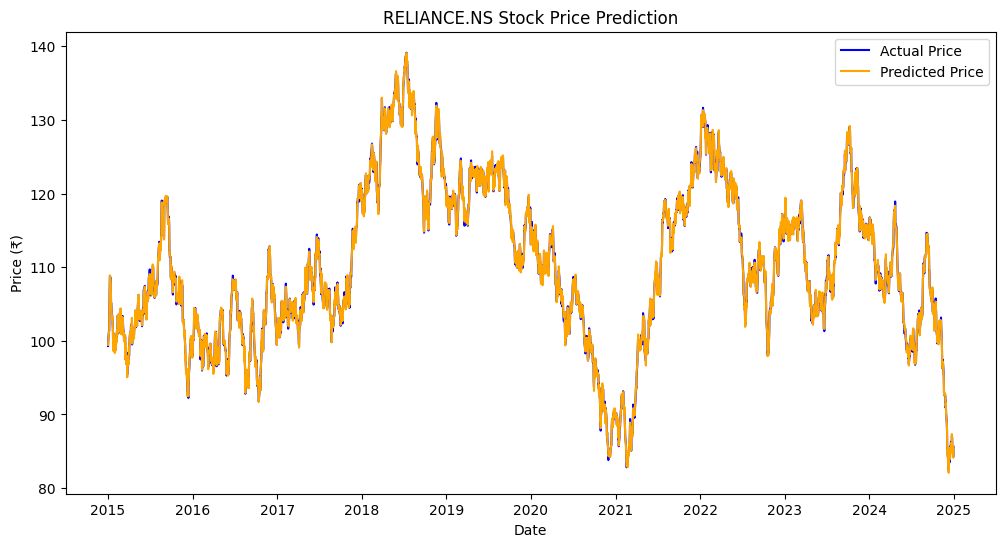

In [9]:
import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf
import os

# Load your accuracy report
report = pd.read_csv("accuracy_report.csv")
print(report)

# Suppose you trained one stock model and want to visualize it
# (Replace ticker symbol as needed)
ticker = "RELIANCE.NS"
basename = ticker.replace(".NS", "_NS")

csv_name = basename + ".csv"
csv_path = os.path.join("data", csv_name)

# Load CSV
data = pd.read_csv(csv_path, parse_dates=['Date'])
data.set_index('Date', inplace=True)

# Predict using your trained model
from joblib import load
model = load(f"models/{basename}_model.joblib")

data['Predicted'] = model.predict(data[['Open', 'High', 'Low', 'Volume']])

plt.figure(figsize=(12, 6))
plt.plot(data.index, data['Close'], label="Actual Price", color='blue')
plt.plot(data.index, data['Predicted'], label="Predicted Price", color='orange')
plt.title(f"{ticker} Stock Price Prediction")
plt.xlabel("Date")
plt.ylabel("Price (₹)")
plt.legend()
plt.show()



In [10]:
import yfinance as yf
import pandas as pd
from sklearn.linear_model import LinearRegression
import joblib
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error
import os

# Stock name (you can change later)
ticker = "RELIANCE.NS"
basename = ticker.replace(".NS", "_NS")

csv_name = basename + ".csv"
csv_path = os.path.join("data", csv_name)

data = pd.read_csv(csv_path, parse_dates=['Date'])
data.set_index('Date', inplace=True)

data["Target"] = data["Close"].shift(-1)
data.dropna(inplace=True)

X = data[["Open", "High", "Low", "Volume"]]
y = data["Target"]

model = LinearRegression()
model.fit(X, y)

preds = model.predict(X)
rmse = np.sqrt(mean_squared_error(y, preds))
mae = mean_absolute_error(y, preds)

joblib.dump(model, f"models/{basename}_model.joblib")

print(f"✅ Model trained and saved for {ticker}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")


✅ Model trained and saved for RELIANCE.NS
RMSE: 1.20
MAE: 0.97


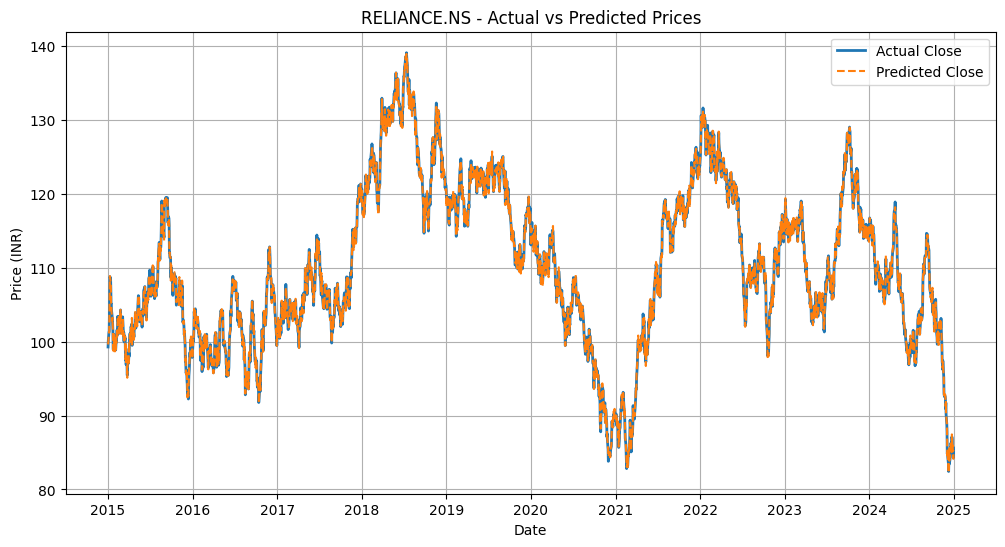

In [11]:
import matplotlib.pyplot as plt
from joblib import load
import pandas as pd
import yfinance as yf
import os

ticker = "RELIANCE.NS"
basename = ticker.replace(".NS", "_NS")

model = load(f"models/{basename}_model.joblib")

csv_name = basename + ".csv"
csv_path = os.path.join("data", csv_name)

data = pd.read_csv(csv_path, parse_dates=['Date'])
data.set_index('Date', inplace=True)

data["Predicted_Close"] = model.predict(data[["Open", "High", "Low", "Volume"]])

plt.figure(figsize=(12, 6))
plt.plot(data.index, data["Close"], label="Actual Close", linewidth=2)
plt.plot(data.index, data["Predicted_Close"], label="Predicted Close", linestyle="--")
plt.title(f"{ticker} - Actual vs Predicted Prices")
plt.xlabel("Date")
plt.ylabel("Price (INR)")
plt.legend()
plt.grid(True)
plt.show()


In [12]:
# Legacy compatibility helper for downstream exploratory cells
import numpy as np

def ensure_legacy_columns(df):
    updated = False
    if 'Close_RELIANCE.NS' not in df.columns and 'Close' in df.columns:
        df['Close_RELIANCE.NS'] = df['Close']
        updated = True
    if 'Predicted_Close_' not in df.columns and 'Predicted_Close' in df.columns:
        df['Predicted_Close_'] = df['Predicted_Close']
        updated = True
    if 'Prev_Close' not in df.columns and 'Close' in df.columns:
        df['Prev_Close'] = df['Close'].shift(1)
        updated = True
    if 'Signal' not in df.columns and 'Predicted_Close' in df.columns and 'Prev_Close' in df.columns:
        df['Signal'] = np.where(df['Predicted_Close'] > df['Prev_Close'], 'BUY', 'SELL')
        updated = True
    return updated

if 'data' in globals():
    changed = ensure_legacy_columns(data)
    if changed:
        print("Legacy compatibility columns added to data frame.")
    else:
        print("Legacy columns already present or data unavailable.")
else:
    print("No global 'data' frame available yet for legacy compatibility adjustments.")



Legacy compatibility columns added to data frame.


In [13]:
# Step 8: Performance matrices (regression metrics)
def show_performance_report(path: str, title: str) -> None:
    csv_path = Path(path)
    if csv_path.exists():
        df = pd.read_csv(csv_path)
        print(f"\n{title} ({csv_path})")
        display(df)
    else:
        print(f"\n{title} not found at {csv_path.resolve()}")

show_performance_report("accuracy_report.csv", "Linear Regression Performance Matrix")
show_performance_report("accuracy_report_RF.csv", "Random Forest Performance Matrix")




Linear Regression Performance Matrix (accuracy_report.csv)


,Stock,Train_MAE,Train_RMSE,Test_MAE,Test_RMSE,Test_R2,Data_Points
0,HDFCBANK,0.228,0.286,0.231,0.293,0.9995,2609
1,ICICIBANK,0.227,0.284,0.228,0.284,0.9976,2609
2,INFY,0.232,0.290,0.223,0.281,0.9988,2609
3,RELIANCE,0.235,0.293,0.233,0.290,0.9989,2609
4,SBIN,0.231,0.289,0.232,0.285,0.9983,2609
5,TCS,0.240,0.301,0.231,0.286,0.9997,2609



Random Forest Performance Matrix (accuracy_report_RF.csv)


,Stock,Model_Type,Train_MAE,Train_RMSE,Train_R2,Test_MAE,Test_RMSE,Test_R2,Data_Points
0,HDFCBANK,Random Forest,0.140,0.179,0.9999,14.312,18.254,-1.0444,2609
1,ICICIBANK,Random Forest,0.136,0.175,0.9999,0.276,0.344,0.9965,2609
2,INFY,Random Forest,0.148,0.187,1.0000,0.948,2.061,0.9371,2609
3,RELIANCE,Random Forest,0.142,0.180,0.9997,0.256,0.323,0.9987,2609
4,SBIN,Random Forest,0.148,0.187,1.0000,0.259,0.321,0.9979,2609
5,TCS,Random Forest,0.148,0.186,0.9999,0.274,0.344,0.9995,2609


In [14]:
# Step 9: Up/Down classification metrics for Linear Regression and Random Forest

def evaluate_updown_models(model_template: str, label: str):
    rows = []
    confusion_tables = {}

    for stock_name in stock_names:
        csv_filename = f"{stock_name}_NS.csv"
        model_path = Path(models_folder) / model_template.format(stock=stock_name)

        if not model_path.exists():
            print(f"{label}: Skipping {stock_name} (model not found)")
            continue

        df = load_stock_data(csv_filename)
        if df is None or len(df) < 50:
            continue

        X = df[['Open', 'High', 'Low', 'Volume']]
        y = df['Close']
        split_idx = int(len(X) * 0.8)
        X_test = X.iloc[split_idx:]
        y_test = y.iloc[split_idx:]

        model = load(model_path)
        y_pred = pd.Series(model.predict(X_test), index=X_test.index)

        prev_close = df['Close'].shift(1).iloc[split_idx:]
        mask = prev_close.notna()
        actual_labels = np.where(y_test[mask] > prev_close[mask], 'Up', 'Down')
        predicted_labels = np.where(y_pred[mask] > prev_close[mask], 'Up', 'Down')

        acc = accuracy_score(actual_labels, predicted_labels)
        precision, recall, f1, _ = precision_recall_fscore_support(
            actual_labels,
            predicted_labels,
            average='weighted',
            zero_division=0,
        )
        cm = confusion_matrix(actual_labels, predicted_labels, labels=['Up', 'Down'])

        confusion_tables[stock_name] = pd.DataFrame(
            cm,
            index=['Actual_Up', 'Actual_Down'],
            columns=['Pred_Up', 'Pred_Down'],
        )
        rows.append(
            {
                'Stock': stock_name,
                'Accuracy': acc,
                'Precision_weighted': precision,
                'Recall_weighted': recall,
                'F1_weighted': f1,
            }
        )

    results_df = pd.DataFrame(rows).round(4)
    if results_df.empty:
        print(f"\nNo {label} metrics were generated.")
    else:
        print(f"\n{label} Up/Down Metrics")
        display(results_df)
        for stock_name, cm_df in confusion_tables.items():
            print(f"\n{label} Confusion Matrix - {stock_name}")
            display(cm_df)

    return results_df

# Evaluate both model families
lr_metrics = evaluate_updown_models("{stock}_NS_model.joblib", "Linear Regression")
rf_metrics = evaluate_updown_models("{stock}_NS_RF_model.joblib", "Random Forest")



✅ Loaded HDFCBANK_NS.csv: 2609 rows, Date range: 2015-01-01 to 2024-12-31
✅ Loaded ICICIBANK_NS.csv: 2609 rows, Date range: 2015-01-01 to 2024-12-31
✅ Loaded INFY_NS.csv: 2609 rows, Date range: 2015-01-01 to 2024-12-31
✅ Loaded RELIANCE_NS.csv: 2609 rows, Date range: 2015-01-01 to 2024-12-31
✅ Loaded SBIN_NS.csv: 2609 rows, Date range: 2015-01-01 to 2024-12-31
✅ Loaded TCS_NS.csv: 2609 rows, Date range: 2015-01-01 to 2024-12-31

Linear Regression Up/Down Metrics


,Stock,Accuracy,Precision_weighted,Recall_weighted,F1_weighted
0,HDFCBANK,0.9100,0.9100,0.9100,0.9099
1,ICICIBANK,0.9157,0.9158,0.9157,0.9157
2,INFY,0.9119,0.9120,0.9119,0.9119
3,RELIANCE,0.9080,0.9081,0.9080,0.9081
4,SBIN,0.9176,0.9177,0.9176,0.9176
5,TCS,0.9195,0.9197,0.9195,0.9196



Linear Regression Confusion Matrix - HDFCBANK


,Pred_Up,Pred_Down
Actual_Up,215,26
Actual_Down,21,260



Linear Regression Confusion Matrix - ICICIBANK


...

,Pred_Up,Pred_Down
Actual_Up,228,23
Actual_Down,29,242



Random Forest Confusion Matrix - SBIN


,Pred_Up,Pred_Down
Actual_Up,227,25
Actual_Down,32,238



Random Forest Confusion Matrix - TCS


,Pred_Up,Pred_Down
Actual_Up,223,26
Actual_Down,22,251


In [15]:
import numpy as np

if 'data' not in globals() or 'Predicted' not in getattr(data, 'columns', []):
    print("Skipping legacy buy/sell chart: 'Predicted' column not available.")
else:
    data['Signal'] = np.where(data['Predicted'] > data['Close'].shift(1), 'BUY', 'SELL')

    plt.figure(figsize=(14, 7))
    plt.plot(data['Close'], label='Actual Price', color='blue')
    plt.plot(data['Predicted'], label='Predicted Price', color='red')

    buy_signals = data[data['Signal'] == 'BUY']
    sell_signals = data[data['Signal'] == 'SELL']

    plt.scatter(
        buy_signals.index,
        buy_signals['Predicted'],
        color='green',
        label='BUY Signal',
        marker='^',
        alpha=1,
    )
    plt.scatter(
        sell_signals.index,
        sell_signals['Predicted'],
        color='black',
        label='SELL Signal',
        marker='v',
        alpha=1,
    )

    symbol = globals().get('ticker', 'selected stock')
    plt.title(f"Buy/Sell Signal Chart for {symbol}")
    plt.xlabel("Date")
    plt.ylabel("Stock Price")
    plt.legend()
    plt.show()


Skipping legacy buy/sell chart: 'Predicted' column not available.


In [16]:
print(data.columns)


Index(['Open', 'High', 'Low', 'Close', 'Volume', 'Predicted_Close',
       'Close_RELIANCE.NS', 'Predicted_Close_', 'Prev_Close', 'Signal'],
      dtype='object')


In [17]:
# Flatten MultiIndex columns to single level
data.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in data.columns]
print(data.columns)


Index(['Open', 'High', 'Low', 'Close', 'Volume', 'Predicted_Close',
       'Close_RELIANCE.NS', 'Predicted_Close_', 'Prev_Close', 'Signal'],
      dtype='object')


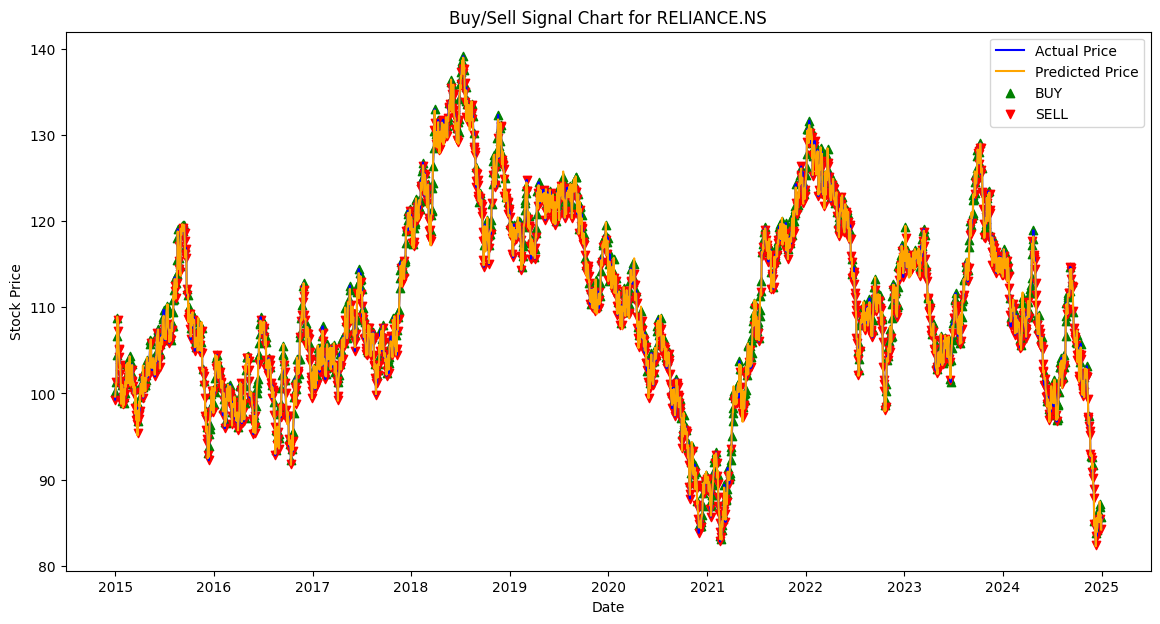

In [18]:
import numpy as np
import matplotlib.pyplot as plt

required_cols = {'Predicted_Close', 'Close_RELIANCE.NS'}
if 'data' not in globals() or not required_cols.issubset(set(getattr(data, 'columns', []))):
    print("Skipping RELIANCE buy/sell chart: required columns missing.")
else:
    data['Signal'] = np.where(
        data['Predicted_Close'] > data['Close_RELIANCE.NS'].shift(1), 'BUY', 'SELL'
    )

    plt.figure(figsize=(14, 7))
    plt.plot(data.index, data['Close_RELIANCE.NS'], label='Actual Price', color='blue')
    plt.plot(data.index, data['Predicted_Close'], label='Predicted Price', color='orange')

    buy_signals = data[data['Signal'] == 'BUY']
    sell_signals = data[data['Signal'] == 'SELL']

    plt.scatter(buy_signals.index, buy_signals['Close_RELIANCE.NS'], label='BUY', marker='^', color='green')
    plt.scatter(sell_signals.index, sell_signals['Close_RELIANCE.NS'], label='SELL', marker='v', color='red')

    plt.title("Buy/Sell Signal Chart for RELIANCE.NS")
    plt.xlabel("Date")
    plt.ylabel("Stock Price")
    plt.legend()
    plt.show()


In [19]:
print(data.columns.tolist())


['Open', 'High', 'Low', 'Close', 'Volume', 'Predicted_Close', 'Close_RELIANCE.NS', 'Predicted_Close_', 'Prev_Close', 'Signal']


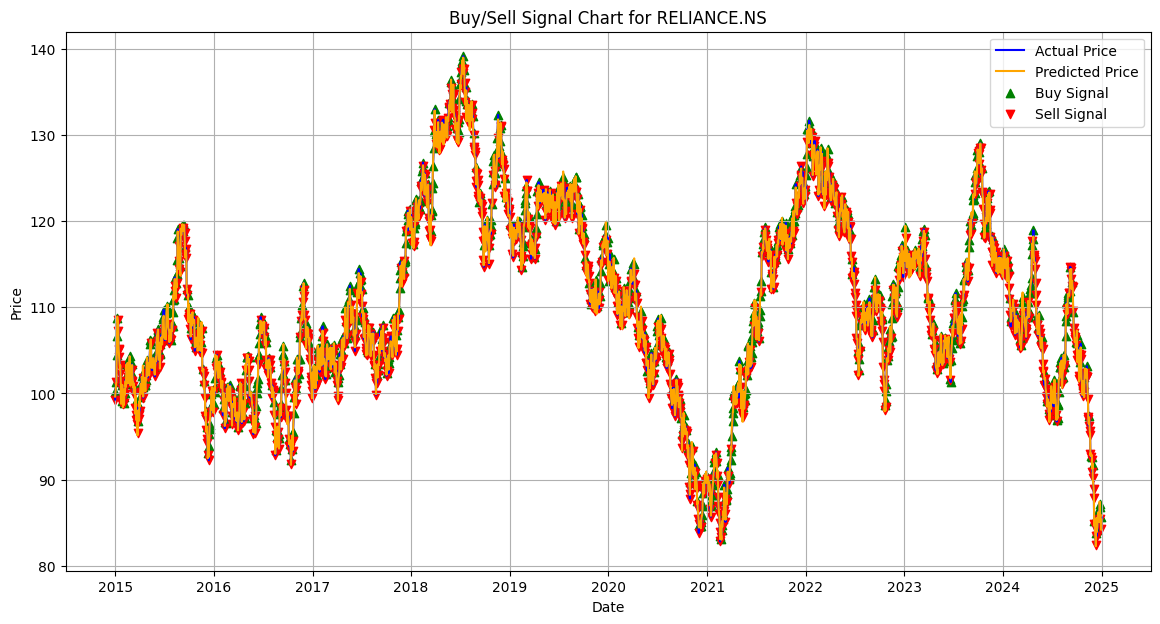

In [20]:
import numpy as np
import matplotlib.pyplot as plt

required_cols = {'Predicted_Close_', 'Close_RELIANCE.NS'}
if 'data' not in globals() or not required_cols.issubset(set(getattr(data, 'columns', []))):
    print("Skipping RELIANCE buy/sell variation: required columns missing.")
else:
    data['Signal'] = np.where(
        data['Predicted_Close_'] > data['Close_RELIANCE.NS'].shift(1), 'BUY', 'SELL'
    )

    plt.figure(figsize=(14, 7))
    plt.plot(data.index, data['Close_RELIANCE.NS'], label='Actual Price', color='blue')
    plt.plot(data.index, data['Predicted_Close_'], label='Predicted Price', color='orange')

    plt.scatter(
        data.index[data['Signal'] == 'BUY'],
        data['Close_RELIANCE.NS'][data['Signal'] == 'BUY'],
        label='Buy Signal',
        marker='^',
        color='green',
        alpha=1,
    )
    plt.scatter(
        data.index[data['Signal'] == 'SELL'],
        data['Close_RELIANCE.NS'][data['Signal'] == 'SELL'],
        label='Sell Signal',
        marker='v',
        color='red',
        alpha=1,
    )

    plt.title("Buy/Sell Signal Chart for RELIANCE.NS")
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.legend()
    plt.grid(True)
    plt.show()


📊 Model Accuracy Report:
       Stock  Train_MAE  Train_RMSE  Test_MAE  Test_RMSE  Test_R2  Data_Points
0   HDFCBANK      0.228       0.286     0.231      0.293   0.9995         2609
1  ICICIBANK      0.227       0.284     0.228      0.284   0.9976         2609
2       INFY      0.232       0.290     0.223      0.281   0.9988         2609
3   RELIANCE      0.235       0.293     0.233      0.290   0.9989         2609
4       SBIN      0.231       0.289     0.232      0.285   0.9983         2609
5        TCS      0.240       0.301     0.231      0.286   0.9997         2609


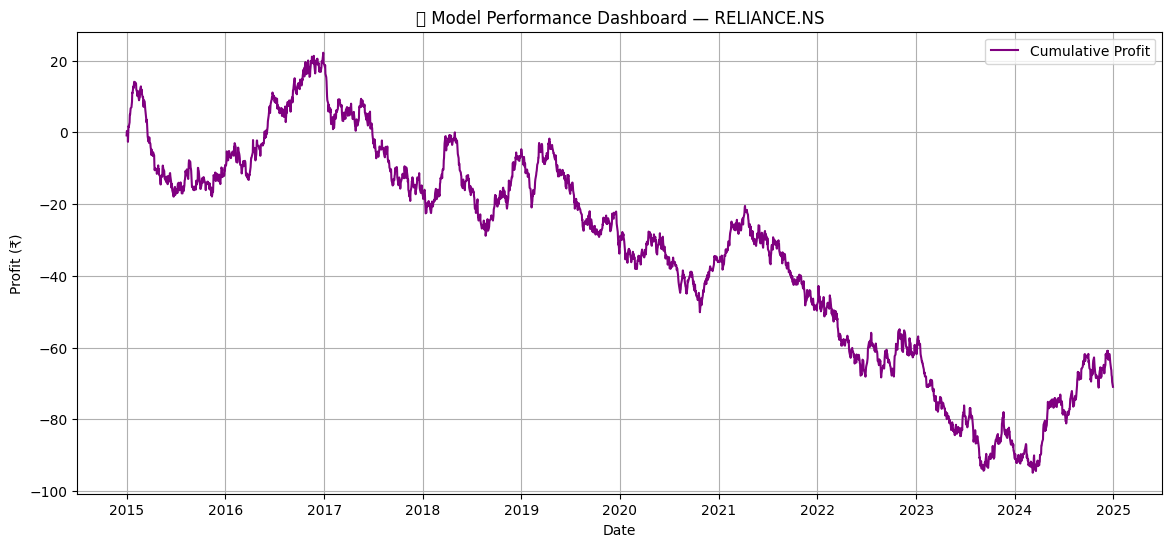


💰 Total Estimated Profit: ₹-70.94


In [21]:
import pandas as pd
import matplotlib.pyplot as plt

report = pd.read_csv("accuracy_report.csv")
print("📊 Model Accuracy Report:")
print(report)

needed_cols = {'Close_RELIANCE.NS', 'Signal'}
if 'data' not in globals() or not needed_cols.issubset(set(getattr(data, 'columns', []))):
    print("Skipping cumulative profit chart: required RELIANCE columns missing.")
else:
    data['Next_Close'] = data['Close_RELIANCE.NS'].shift(-1)
    data['Profit'] = np.where(
        data['Signal'] == 'BUY',
        data['Next_Close'] - data['Close_RELIANCE.NS'],
        data['Close_RELIANCE.NS'] - data['Next_Close'],
    )
    data['Cumulative_Profit'] = data['Profit'].cumsum()

    plt.figure(figsize=(14, 6))
    plt.plot(data.index, data['Cumulative_Profit'], color='purple', label='Cumulative Profit')
    plt.title("📈 Model Performance Dashboard — RELIANCE.NS")
    plt.xlabel("Date")
    plt.ylabel("Profit (₹)")
    plt.legend()
    plt.grid(True)
    plt.show()

    total_profit = data['Cumulative_Profit'].iloc[-2]
    print(f"\n💰 Total Estimated Profit: ₹{total_profit:.2f}")
